# The magnet-to-magnet track dataset (Block C, C0)

This notebook **computes nothing**. It loads what `check_polarity.py`,
`build_dataset.py`, `plot_schematic.py` and `plot_population.py` wrote.
The argument is in [README.md](README.md).


In [1]:
import os
for _v in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS",
           "NUMEXPR_NUM_THREADS"):
    os.environ[_v] = "1"
os.environ["PYTHONNOUSERSITE"] = "1"
import json
import numpy as np
import pandas as pd
from IPython.display import Image, display
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
RESULTS, FIGURES = "results", "figures"


## The field polarity

The first thing C0 had to settle, and it did not go the way the repository
assumed. See `check_polarity.py`.

In [2]:
pol_ = json.load(open(os.path.join(RESULTS, "polarity_check.json")))
print(pol_["verdict"])
print()
for c in pol_["consequence"]:
    print(" *", c)


MagUp. The forward cross-magnet leg lands 1.73 mm from the particle's real first-SciFi state with the up map and 883 mm with the down map, and the sign of the bend is right for 100.0% of particles with up against 0.0% with down. The up-map residual falls as 1/p, which is the multiple-scattering line the training set's own G2 gate reports for the short legs - i.e. exactly the material effect that is out of the label's scope by design. The down-map residual is the deflection itself, doubled.

 * the v2 training set's labels (train_official_v2.npz) do not describe the events they were harvested from; the Y column is the field-only propagation of the right start state through the wrong polarity
 * experiments that only ever compared a network with that same engine (One_step_network_v2, General_leg_network, Chained_legs, ...) are internally consistent and their conclusions about how well a network solves the scheme stand; what does not stand is any claim that those labels are where the simu

In [3]:
def band(x):
    return "all" if x == "all" else "%g-%g GeV" % tuple(x)

key = "forward: UT -> first SciFi plane"
rows = []
for pol in ("up", "down"):
    for r in pol_["propagation_test"]["by_polarity"][pol][key]:
        rows.append({"p band": band(r["p_band_GeV"]), "polarity": pol,
                     "n": r["n"], "median miss [mm]": r["median_mm"],
                     "p95 [mm]": r["p95_mm"],
                     "bend sign right": r["bend_sign_correct_fraction"]})
pd.DataFrame(rows).pivot_table(index="p band", columns="polarity",
                               values=["median miss [mm]", "bend sign right"],
                               sort=False)


median miss [mm]              bend sign right     
polarity                 up         down              up down
p band                                                       
1-2 GeV           14.832148  3973.400052             1.0  0.0
2-5 GeV            5.128781  1855.967483             1.0  0.0
5-10 GeV           1.615761   892.158283             1.0  0.0
10-25 GeV          0.646323   417.691141             1.0  0.0
25-200 GeV         0.276303   168.948390             1.0  0.0
all                1.727512   883.470619             1.0  0.0

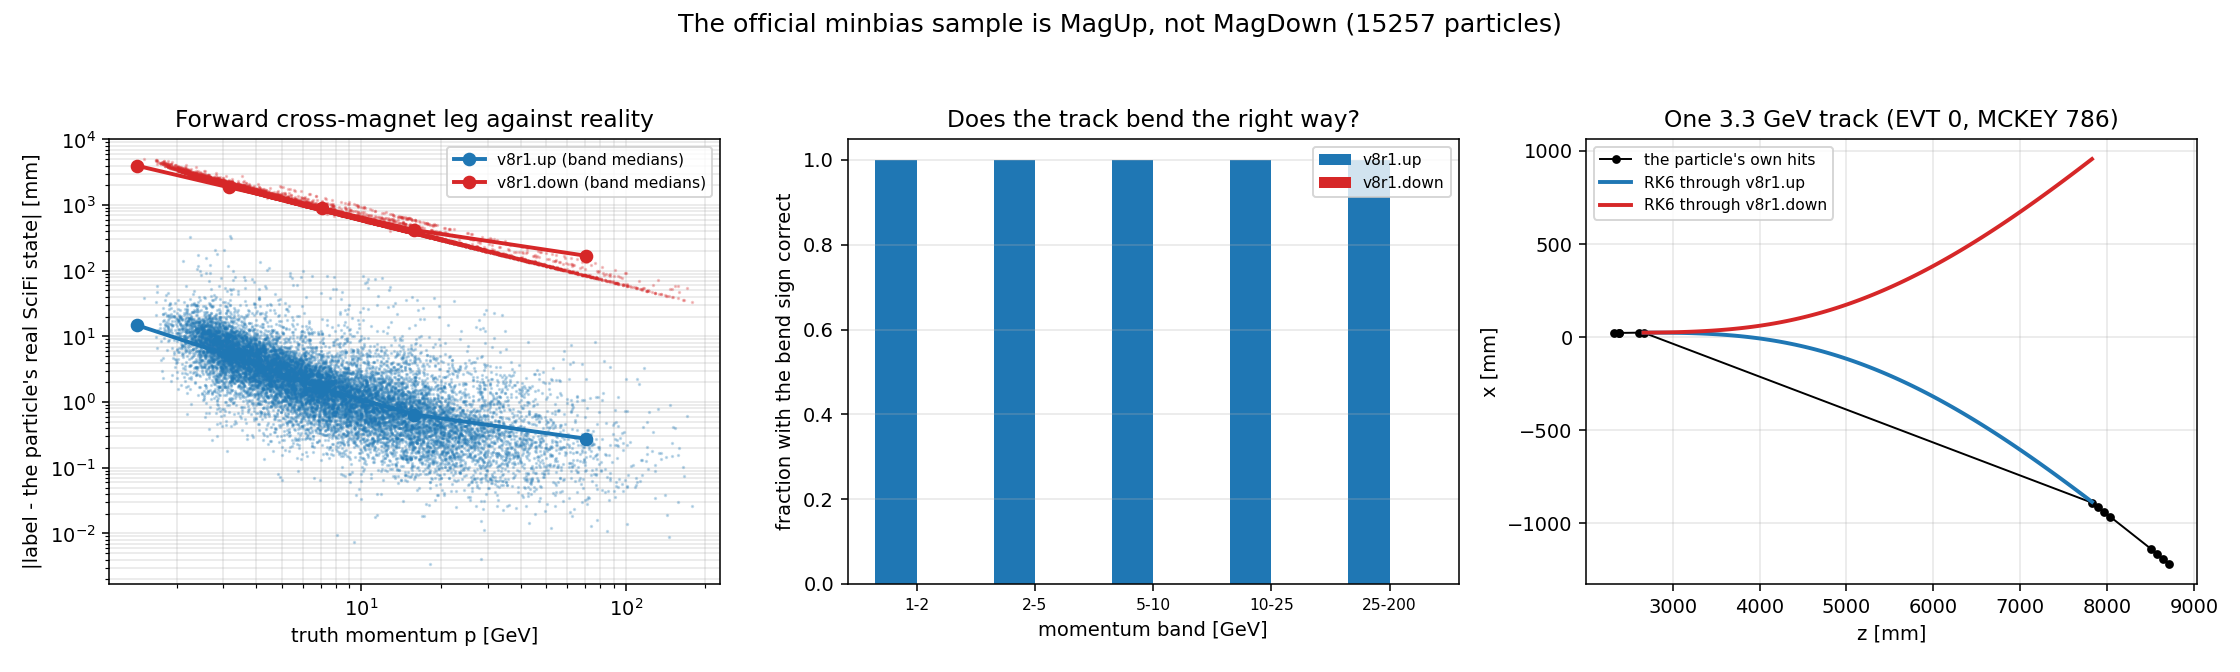

In [4]:
display(Image(filename=os.path.join(FIGURES, "field_polarity.png")))

## C0.1 The cut cascade

In [5]:
meta = json.load(open(os.path.join(RESULTS, "dataset_meta.json")))
pd.DataFrame(meta["cut_cascade"])[
    ["cut", "rows_in", "rows_removed", "rows_out", "particles_out"]]


,cut,rows_in,rows_removed,rows_out,particles_out
0,leg-B rows in the training set (both directions),41398,0,41398,21932
1,pre-magnet plane is a UT plane,41398,2476,38922,20655
2,both directions kept for the particle,38922,2388,36534,18267
3,2 < eta < 5,36534,1240,35294,17647
4,1 < p < 200 GeV,35294,0,35294,17647
5,non-electron,35294,4780,30514,15257
6,both directions still kept after the cuts,30514,0,30514,15257
7,compute cap: 6000 particles drawn at random,30514,18514,12000,6000
8,fiducial: the whole RK6 path stays inside the ...,12000,0,12000,6000


## C0.3 / C0.4 What came out

In [6]:
rows = []
for name, block in meta["counts_per_stratum_direction_split"].items():
    for sp in ("train", "val", "test"):
        rows.append({"stratum": name, "split": sp,
                     "dz>0": block[sp]["forward(dz>0)"],
                     "dz<0": block[sp]["backward(dz<0)"],
                     "total": block[sp]["total"]})
pd.DataFrame(rows).pivot_table(index="stratum", columns="split",
                               values=["dz>0", "dz<0", "total"])


dz<0                    dz>0                   total                
split            test   train     val    test   train     val    test   train     val
stratum                                                                              
0.05-0.2 mm     983.0  3003.0  1017.0  1017.0  2997.0   983.0  2000.0  6000.0  2000.0
0.5-2 mm       1000.0  3024.0   986.0  1000.0  2976.0  1014.0  2000.0  6000.0  2000.0
5-20 mm        1006.0  3036.0   970.0   994.0  2964.0  1030.0  2000.0  6000.0  2000.0
50-200 mm      1032.0  2998.0  1011.0   968.0  3002.0   989.0  2000.0  6000.0  2000.0
500-2000 mm    1012.0  2960.0  1025.0   988.0  3040.0   975.0  2000.0  6000.0  2000.0
full crossing   999.0  2986.0  1007.0  1001.0  3014.0   993.0  2000.0  6000.0  2000.0

In [7]:
print(json.dumps(meta["legs"], indent=1))
print(json.dumps(meta["split"], indent=1))
print(json.dumps(meta["clipping"], indent=1))
print(json.dumps(meta["counts_per_momentum_band"], indent=1))


{
 "n_legs": 12000,
 "n_particles": 6000,
 "forward": 6000,
 "backward": 6000,
 "dense_states": 6258634
}
{
 "by": "particle",
 "seed": 20260718,
 "fractions": [
  0.6,
  0.2,
  0.2
 ],
 "particles": {
  "train": 3600,
  "val": 1200,
  "test": 1200
 },
 "warning": "this is NOT the v2 training set's 80/10/10 split; a particle in this set's train split may be in the v2 test split. The v2 label is carried as SPLIT_V2 in the dense file for anyone who needs to intersect them."
}
{
 "direction_flipped_to_fit": 2390,
 "magnitude_clipped_to_the_window": 0,
 "rule": "the drawn direction is used if the step fits inside [UT plane, SciFi plane]; otherwise it is flipped; |dz| is clipped only if neither fits"
}
{
 "1-2": {
  "all": 327,
  "train": 209,
  "val": 76,
  "test": 42
 },
 "2-5": {
  "all": 20692,
  "train": 12382,
  "val": 4048,
  "test": 4262
 },
 "5-10": {
  "all": 17545,
  "train": 10684,
  "val": 3167,
  "test": 3694
 },
 "10-25": {
  "all": 15445,
  "train": 9305,
  "val": 3413,
  "t

In [8]:
import use_shared                                    # noqa: F401
from _shared.prepare import load_magnet_tracks
d = load_magnet_tracks(os.path.join(RESULTS, "magnet_tracks_v3.npz"), split="test")
print({k: v.shape for k, v in d.items() if hasattr(v, "shape")})
pd.DataFrame(d["X"][:5], columns=["x", "y", "tx", "ty", "qop", "z0", "dz"])


{'X': (12000, 7), 'Y': (12000, 5), 'STRATUM': (12000,), 'DIRECTION': (12000,), 'LEG_DIR': (12000,), 'P': (12000,), 'ETA': (12000,), 'PID': (12000,), 'EVT': (12000,), 'MCKEY': (12000,), 'SPLIT': (12000,), 'LEG_INDEX': (12000,), 'stratum_names': (6,), 'p_bands': (5, 2), 'rk6_step_mm': (), 'sample_mm': (), 'field': (), 'seed': ()}


,x,y,tx,ty,qop,z0,dz
0,-11.148320,-137.738642,-0.015628,-0.026829,0.008466,5116.846436,-0.082699
1,58.298365,-37.475740,0.019745,-0.008934,-0.007148,4185.847168,-0.073827
2,-71.075166,226.922430,0.035842,0.048625,-0.041711,4667.468262,-0.051020
3,-124.722126,-80.335844,-0.077503,-0.013355,0.026808,5995.722168,0.071677
4,-236.351479,195.049442,-0.095893,0.027290,0.025080,7111.846436,-0.193951


## C0.5 The figures

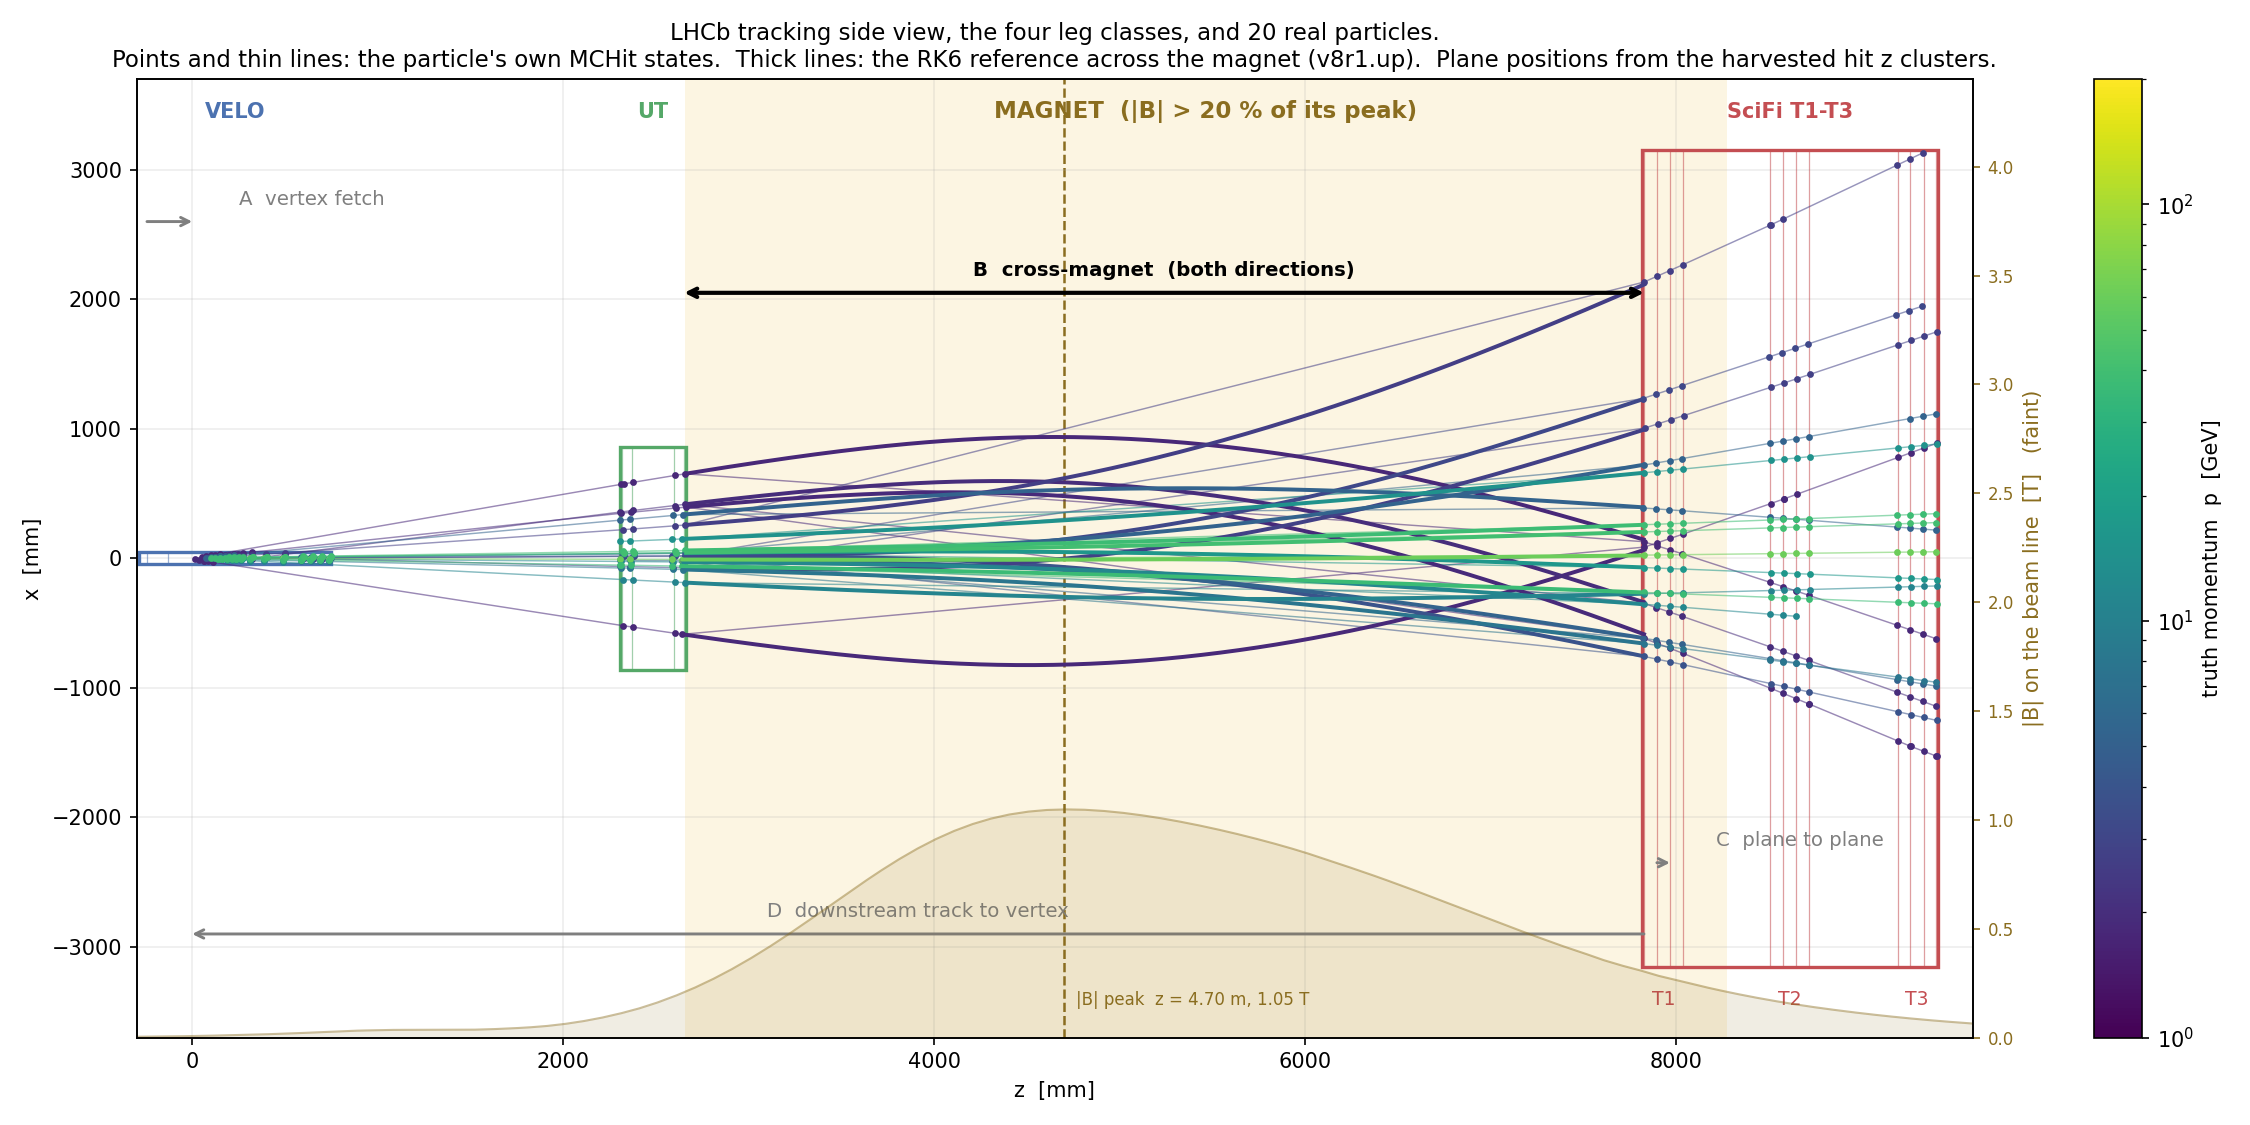

In [9]:
display(Image(filename=os.path.join(FIGURES, "lhcb_legs_schematic.png")))

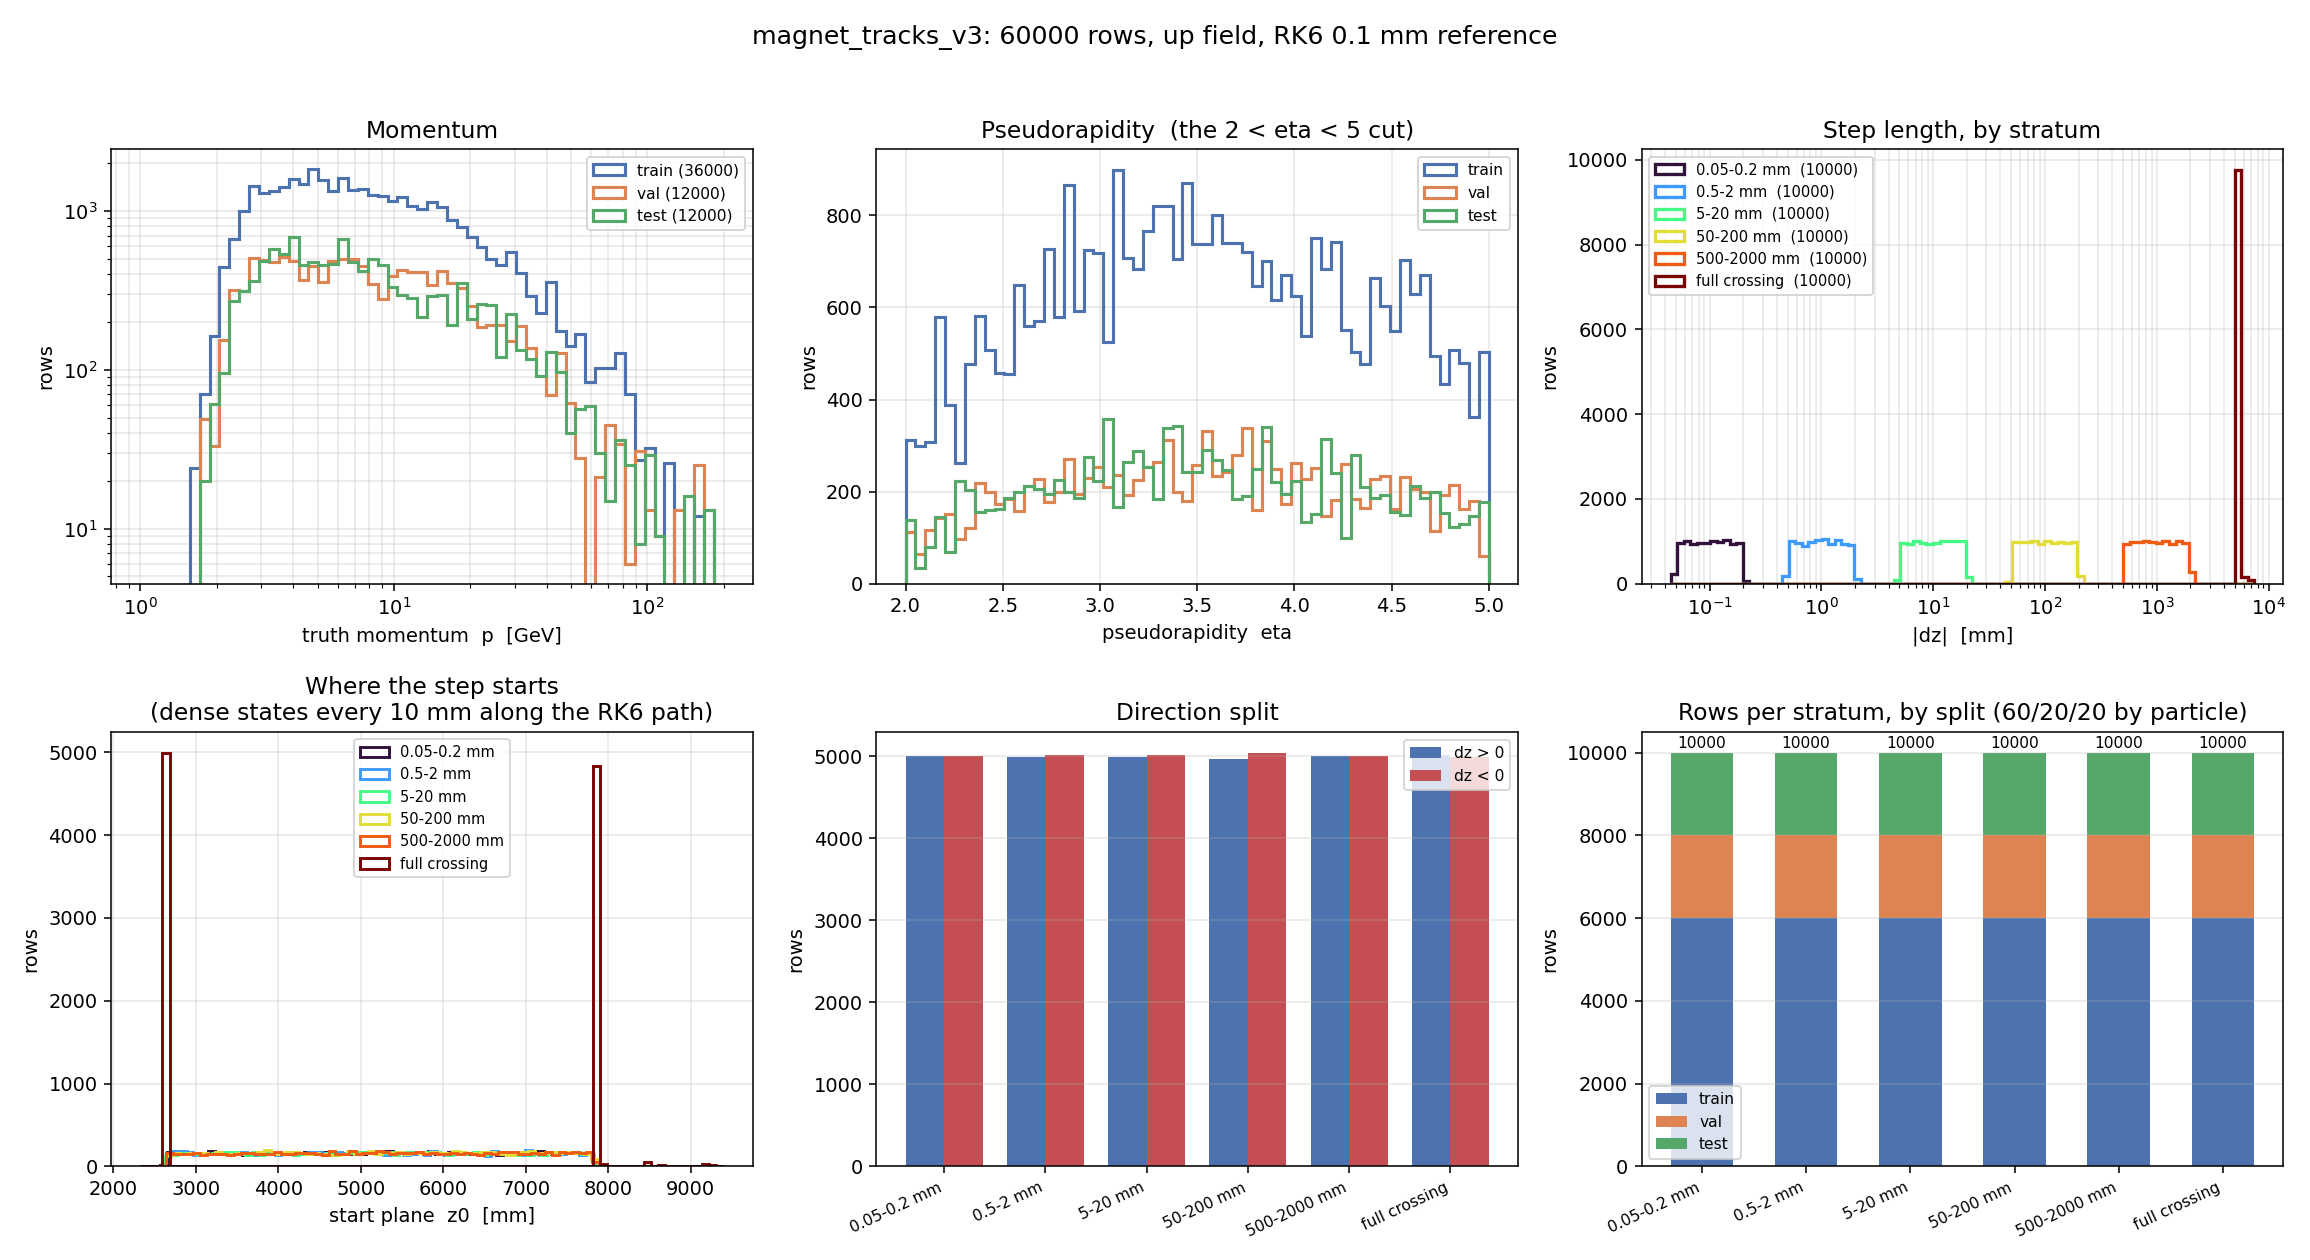

In [10]:
display(Image(filename=os.path.join(FIGURES, "dataset_population.png")))